In [2]:
from datasets import load_dataset

ds = load_dataset("facebook/asset")

README.md: 0.00B [00:00, ?B/s]

simplification/validation-00000-of-00001(…):   0%|          | 0.00/885k [00:00<?, ?B/s]

simplification/test-00000-of-00001.parqu(…):   0%|          | 0.00/170k [00:00<?, ?B/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/359 [00:00<?, ? examples/s]

In [4]:
!pip -q install datasets pyarrow spacy
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 58.9 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [5]:
print(ds)

for split in ds:
    print("\n", split)
    print(ds[split].features)
    print(ds[split][0])

DatasetDict({
    validation: Dataset({
        features: ['original', 'simplifications'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['original', 'simplifications'],
        num_rows: 359
    })
})

 validation
{'original': Value('string'), 'simplifications': List(Value('string'))}
{'original': 'Adjacent counties are Marin (to the south), Mendocino (to the north), Lake (northeast), Napa (to the east), and Solano and Contra Costa (to the southeast).', 'simplifications': ['countries next to it are Marin, Mendocino, Lake, Napa, Solano, and Contra Costa.', 'Nearby counties are Marin, Mendocino, Lake, Napa, and Solano and Contra Costa.', 'Adjacent counties are Marin, Mendocino, Lake, Napa, Solano and Contra Costa.', 'Neighboring counties are Marin, Mendocino, Lake, Napa, Solano, and Contra Costa.', 'Adjacent counties are Marin (south), Mendocino (north), Lake (northeast), and Napa (east). Solano and Contra Costa are to the southeast.', 'Counties next to it are Mari

# Building the DS

In [11]:
import pandas as pd
import numpy as np

def build_classification_pairs(
    df,
    normal_col="Normal",
    simple_col="Simple",
    dataset_name="ASSET"
):
    df = df[[normal_col, simple_col]].copy()

    df = df.dropna()

    df[normal_col] = df[normal_col].astype(str).str.strip()
    df[simple_col] = df[simple_col].astype(str).str.strip()

    df = df[
        (df[normal_col] != "") &
        (df[simple_col] != "")
    ].reset_index(drop=True)

    df["pair_id"] = np.arange(len(df))
    df["dataset"] = dataset_name

    normal_df = pd.DataFrame({
        "dataset": dataset_name,
        "pair_id": df["pair_id"],
        "text": df[normal_col],
        "label": 0,
        "label_name": "normal",
        "paired_text": df[simple_col]
    })

    simple_df = pd.DataFrame({
        "dataset": dataset_name,
        "pair_id": df["pair_id"],
        "text": df[simple_col],
        "label": 1,
        "label_name": "simplified",
        "paired_text": df[normal_col]
    })

    clf_df = pd.concat(
        [normal_df, simple_df],
        ignore_index=True
    )

    return df, clf_df

In [12]:


def build_asset_pairs(ds, splits=("validation", "test")):
    rows = []

    pair_id = 0

    for split in splits:
        for example in ds[split]:
            original = str(example["original"]).strip()

            for ref_id, simplification in enumerate(example["simplifications"]):
                simple = str(simplification).strip()

                if original and simple:
                    rows.append({
                        "dataset": "ASSET",
                        "split": split,
                        "pair_id": pair_id,
                        "source_id": f"{split}_{pair_id}",
                        "ref_id": ref_id,
                        "Normal": original,
                        "Simple": simple
                    })
                    pair_id += 1

    return pd.DataFrame(rows)

pairs_asset = build_asset_pairs(ds)

print("Pairs:", pairs_asset.shape)
display(pairs_asset.head())
display(pairs_asset["split"].value_counts())

Pairs: (23590, 7)


,dataset,split,pair_id,source_id,ref_id,Normal,Simple
0,ASSET,validation,0,validation_0,0,"Adjacent counties are Marin (to the south), Me...","countries next to it are Marin, Mendocino, Lak..."
1,ASSET,validation,1,validation_1,1,"Adjacent counties are Marin (to the south), Me...","Nearby counties are Marin, Mendocino, Lake, Na..."
2,ASSET,validation,2,validation_2,2,"Adjacent counties are Marin (to the south), Me...","Adjacent counties are Marin, Mendocino, Lake, ..."
3,ASSET,validation,3,validation_3,3,"Adjacent counties are Marin (to the south), Me...","Neighboring counties are Marin, Mendocino, Lak..."
4,ASSET,validation,4,validation_4,4,"Adjacent counties are Marin (to the south), Me...","Adjacent counties are Marin (south), Mendocino..."


split
validation    20000
test           3590
Name: count, dtype: int64

# Classification DS

In [13]:
pairs_asset_clean, clf_asset = build_classification_pairs(
    pairs_asset,
    normal_col="Normal",
    simple_col="Simple",
    dataset_name="ASSET"
)

print("Pairs clean:", pairs_asset_clean.shape)
print("Classification dataset:", clf_asset.shape)
display(clf_asset["label_name"].value_counts())
display(clf_asset.head())

Pairs clean: (23590, 4)
Classification dataset: (47180, 6)


label_name
normal        23590
simplified    23590
Name: count, dtype: int64

,dataset,pair_id,text,label,label_name,paired_text
0,ASSET,0,"Adjacent counties are Marin (to the south), Me...",0,normal,"countries next to it are Marin, Mendocino, Lak..."
1,ASSET,1,"Adjacent counties are Marin (to the south), Me...",0,normal,"Nearby counties are Marin, Mendocino, Lake, Na..."
2,ASSET,2,"Adjacent counties are Marin (to the south), Me...",0,normal,"Adjacent counties are Marin, Mendocino, Lake, ..."
3,ASSET,3,"Adjacent counties are Marin (to the south), Me...",0,normal,"Neighboring counties are Marin, Mendocino, Lak..."
4,ASSET,4,"Adjacent counties are Marin (to the south), Me...",0,normal,"Adjacent counties are Marin (south), Mendocino..."


# Pair/Source-Aware Leakage Check

In [17]:
from sklearn.model_selection import StratifiedGroupKFold

# group_id = same original sentence gets same group
group_map = (
    pairs_asset_clean[["pair_id", "Normal"]]
    .drop_duplicates("pair_id")
    .copy()
)

group_map["group_id"] = group_map["Normal"].astype("category").cat.codes

clf_asset = clf_asset.merge(
    group_map[["pair_id", "group_id"]],
    on="pair_id",
    how="left"
)

print(clf_asset[["pair_id", "group_id"]].head())
print("Missing group_id:", clf_asset["group_id"].isna().sum())
print("Number of source groups:", clf_asset["group_id"].nunique())

X = clf_asset["text"]
y = clf_asset["label"]
groups = clf_asset["group_id"]

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups), 1):
    train_groups = set(clf_asset.iloc[train_idx]["group_id"])
    test_groups = set(clf_asset.iloc[test_idx]["group_id"])

    overlap = train_groups.intersection(test_groups)

    print(f"Fold {fold}")
    print("Train size:", len(train_idx))
    print("Test size:", len(test_idx))
    print("Train label distribution:")
    print(clf_asset.iloc[train_idx]["label_name"].value_counts(normalize=True))
    print("Test label distribution:")
    print(clf_asset.iloc[test_idx]["label_name"].value_counts(normalize=True))
    print("Source leakage:", len(overlap))
    print("-" * 50)

   pair_id  group_id
0        0       106
1        1       106
2        2       106
3        3       106
4        4       106
Missing group_id: 0
Number of source groups: 2359
Fold 1
Train size: 37740
Test size: 9440
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Source leakage: 0
--------------------------------------------------
Fold 2
Train size: 37740
Test size: 9440
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Source leakage: 0
--------------------------------------------------
Fold 3
Train size: 37740
Test size: 9440
Train label distribution:
label_name
normal        0.5
simplified    0.5
Name: proportion, dtype: float64
Test label distribution:
label_name

# Readability Feature Extraction

In [14]:
import re
import string



def tokenize_words(text):
    return re.findall(r"\b\w+\b", str(text).lower())


def extract_readability_features(clf_df):
    df = clf_df[
        ["dataset", "pair_id", "text", "label", "label_name"]
    ].copy()

    words = df["text"].apply(tokenize_words)

    df["sentence_len"] = words.apply(len)

    df["avg_word_len"] = words.apply(
        lambda toks: np.mean([len(w) for w in toks]) if toks else 0
    )

    df["type_token_ratio"] = words.apply(
        lambda toks: len(set(toks)) / len(toks) if toks else 0
    )

    df["char_len"] = df["text"].astype(str).str.len()

    df["punctuation_ratio"] = df["text"].apply(
        lambda txt:
            sum(ch in string.punctuation for ch in str(txt))
            / max(len(str(txt)), 1)
    )

    return df


readability_asset = extract_readability_features(clf_asset)

print(readability_asset.shape)

display(readability_asset.head())

display(
    readability_asset.groupby("label_name")[
        [
            "sentence_len",
            "avg_word_len",
            "type_token_ratio",
            "char_len",
            "punctuation_ratio"
        ]
    ].mean()
)

(47180, 10)


,dataset,pair_id,text,label,label_name,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio
0,ASSET,0,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774
1,ASSET,1,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774
2,ASSET,2,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774
3,ASSET,3,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774
4,ASSET,4,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774


,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio
label_name,,,,,
normal,19.486223,4.931250,0.907649,116.774057,0.026797
simplified,17.058796,4.725311,0.917823,98.522721,0.027396


# Variant Feature Extraction

In [15]:
from difflib import SequenceMatcher
import pandas as pd


def sequence_op_features(normal_text, simple_text):
    normal_tokens = tokenize_words(normal_text)
    simple_tokens = tokenize_words(simple_text)

    matcher = SequenceMatcher(None, normal_tokens, simple_tokens)

    same = replace = insert = delete = 0

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "equal":
            same += max(i2 - i1, j2 - j1)
        elif tag == "replace":
            replace += max(i2 - i1, j2 - j1)
        elif tag == "insert":
            insert += (j2 - j1)
        elif tag == "delete":
            delete += (i2 - i1)

    total = same + replace + insert + delete
    normal_len = len(normal_tokens)
    simple_len = len(simple_tokens)

    return {
        "same_ratio": same / total if total else 0,
        "replace_ratio": replace / total if total else 0,
        "insert_ratio": insert / total if total else 0,
        "delete_ratio": delete / total if total else 0,
        "compression_ratio": simple_len / normal_len if normal_len else 0,
        "length_diff_ratio": (normal_len - simple_len) / normal_len if normal_len else 0,
    }


def extract_variant_features(pairs_df, normal_col="Normal", simple_col="Simple"):
    rows = []

    for _, row in pairs_df.iterrows():
        feats = sequence_op_features(row[normal_col], row[simple_col])
        feats["dataset"] = row["dataset"]
        feats["pair_id"] = row["pair_id"]
        rows.append(feats)

    return pd.DataFrame(rows)


variant_asset = extract_variant_features(
    pairs_asset_clean,
    normal_col="Normal",
    simple_col="Simple"
)

print(variant_asset.shape)
display(variant_asset.head())
display(variant_asset.describe())

(23590, 8)


,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,dataset,pair_id
0,0.333333,0.148148,0.000000,0.518519,0.52,0.48,ASSET,0
1,0.440000,0.040000,0.000000,0.520000,0.48,0.52,ASSET,1
2,0.440000,0.000000,0.000000,0.560000,0.44,0.56,ASSET,2
3,0.400000,0.040000,0.000000,0.560000,0.44,0.56,ASSET,3
4,0.666667,0.000000,0.074074,0.259259,0.80,0.20,ASSET,4


,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,pair_id
count,23590.000000,23590.000000,23590.000000,23590.000000,23590.000000,23590.000000,23590.000000
mean,0.630234,0.193825,0.047274,0.128667,0.892324,0.107676,11794.500000
std,0.207254,0.175158,0.088761,0.148239,0.193327,0.193327,6809.990761
min,0.000000,0.000000,0.000000,0.000000,0.153846,-1.571429,0.000000
25%,0.484848,0.055556,0.000000,0.000000,0.777778,0.000000,5897.250000
50%,0.653846,0.157895,0.000000,0.076923,0.909091,0.090909,11794.500000
75%,0.800000,0.291667,0.062500,0.212121,1.000000,0.222222,17691.750000
max,1.000000,1.000000,0.615385,0.846154,2.571429,0.846154,23589.000000


# Save

In [16]:
readability_asset.to_parquet("asset_readability.parquet", index=False)
variant_asset.to_parquet("asset_variant.parquet", index=False)

print("Saved:")
print("asset_readability.parquet")
print("asset_variant.parquet")

Saved:
asset_readability.parquet
asset_variant.parquet


# Enhanced Feature Extraction

In [18]:
!python -m spacy download en_core_web_sm

import spacy
from tqdm.auto import tqdm
from difflib import SequenceMatcher

nlp = spacy.load("en_core_web_sm", disable=["ner", "parser"])

def spacy_docs_to_features(texts, batch_size=1000):
    docs = []
    for doc in tqdm(nlp.pipe(texts, batch_size=batch_size), total=len(texts)):
        docs.append([
            {
                "text": token.text.lower(),
                "lemma": token.lemma_.lower(),
                "pos": token.pos_
            }
            for token in doc
            if not token.is_space and not token.is_punct
        ])
    return docs

normal_texts = pairs_asset_clean["Normal"].astype(str).tolist()
simple_texts = pairs_asset_clean["Simple"].astype(str).tolist()

normal_docs = spacy_docs_to_features(normal_texts)
simple_docs = spacy_docs_to_features(simple_texts)

print(len(normal_docs), len(simple_docs))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 74.5 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


  0%|          | 0/23590 [00:00<?, ?it/s]

  0%|          | 0/23590 [00:00<?, ?it/s]

23590 23590


In [19]:
def enhanced_features_from_docs(normal_tokens, simple_tokens):
    normal_words = [t["text"] for t in normal_tokens]
    simple_words = [t["text"] for t in simple_tokens]

    matcher = SequenceMatcher(None, normal_words, simple_words)

    lemma_same = lemma_total = 0
    pos_same = pos_total = 0

    for tag, i1, i2, j1, j2 in matcher.get_opcodes():
        if tag == "replace":
            normal_span = normal_tokens[i1:i2]
            simple_span = simple_tokens[j1:j2]
            L = min(len(normal_span), len(simple_span))

            for k in range(L):
                lemma_total += 1
                pos_total += 1

                if normal_span[k]["lemma"] == simple_span[k]["lemma"]:
                    lemma_same += 1
                if normal_span[k]["pos"] == simple_span[k]["pos"]:
                    pos_same += 1

    return {
        "lemma_ratio": lemma_same / lemma_total if lemma_total else 0,
        "pos_ratio": pos_same / pos_total if pos_total else 0,
    }

rows = []

for i in tqdm(range(len(pairs_asset_clean))):
    feats = enhanced_features_from_docs(normal_docs[i], simple_docs[i])
    feats["dataset"] = "ASSET"
    feats["pair_id"] = pairs_asset_clean.iloc[i]["pair_id"]
    rows.append(feats)

enhanced_asset = pd.DataFrame(rows)

print(enhanced_asset.shape)
display(enhanced_asset.head())
display(enhanced_asset.describe())

enhanced_asset.to_parquet("asset_enhanced.parquet", index=False)
print("Saved asset_enhanced.parquet")

  0%|          | 0/23590 [00:00<?, ?it/s]

(23590, 4)


,lemma_ratio,pos_ratio,dataset,pair_id
0,0.0,0.0,ASSET,0
1,0.0,1.0,ASSET,1
2,0.0,0.0,ASSET,2
3,0.0,0.0,ASSET,3
4,0.0,0.0,ASSET,4


,lemma_ratio,pos_ratio,pair_id
count,23590.000000,23590.000000,23590.000000
mean,0.024516,0.372563,11794.500000
std,0.117784,0.398226,6809.990761
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,5897.250000
50%,0.000000,0.250000,11794.500000
75%,0.000000,0.666667,17691.750000
max,1.000000,1.000000,23589.000000


Saved asset_enhanced.parquet


# Building the Modeling Pipeline

In [20]:
from scipy.sparse import hstack, csr_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.preprocessing import RobustScaler

READABILITY_COLS = [
    "sentence_len",
    "avg_word_len",
    "type_token_ratio",
    "char_len",
    "punctuation_ratio"
]

VARIANT_COLS = [
    "same_ratio",
    "replace_ratio",
    "insert_ratio",
    "delete_ratio",
    "compression_ratio",
    "length_diff_ratio"
]

ENHANCED_COLS = [
    "lemma_ratio",
    "pos_ratio"
]


def merge_features(
    clf_df,
    readability_df,
    variant_df=None,
    enhanced_df=None
):

    base = clf_df[
        ["dataset", "pair_id", "group_id", "text", "label", "label_name"]
    ].copy()

    base = base.merge(
        readability_df[
            ["dataset","pair_id","text","label"] + READABILITY_COLS
        ],
        on=["dataset","pair_id","text","label"],
        how="left"
    )

    if variant_df is not None:
        base = base.merge(
            variant_df[
                ["dataset","pair_id"] + VARIANT_COLS
            ],
            on=["dataset","pair_id"],
            how="left"
        )

    if enhanced_df is not None:
        base = base.merge(
            enhanced_df[
                ["dataset","pair_id"] + ENHANCED_COLS
            ],
            on=["dataset","pair_id"],
            how="left"
        )

    return base


model_df_asset_enhanced = merge_features(
    clf_asset,
    readability_asset,
    variant_asset,
    enhanced_asset
)

print(model_df_asset_enhanced.shape)

display(model_df_asset_enhanced.head())

print(model_df_asset_enhanced.isna().sum())

(47180, 19)


,dataset,pair_id,group_id,text,label,label_name,sentence_len,avg_word_len,type_token_ratio,char_len,punctuation_ratio,same_ratio,replace_ratio,insert_ratio,delete_ratio,compression_ratio,length_diff_ratio,lemma_ratio,pos_ratio
0,ASSET,0,106,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774,0.333333,0.148148,0.000000,0.518519,0.52,0.48,0.0,0.0
1,ASSET,1,106,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774,0.440000,0.040000,0.000000,0.520000,0.48,0.52,0.0,1.0
2,ASSET,2,106,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774,0.440000,0.000000,0.000000,0.560000,0.44,0.56,0.0,0.0
3,ASSET,3,106,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774,0.400000,0.040000,0.000000,0.560000,0.44,0.56,0.0,0.0
4,ASSET,4,106,"Adjacent counties are Marin (to the south), Me...",0,normal,25,4.64,0.72,155,0.096774,0.666667,0.000000,0.074074,0.259259,0.80,0.20,0.0,0.0


dataset              0
pair_id              0
group_id             0
text                 0
label                0
label_name           0
sentence_len         0
avg_word_len         0
type_token_ratio     0
char_len             0
punctuation_ratio    0
same_ratio           0
replace_ratio        0
insert_ratio         0
delete_ratio         0
compression_ratio    0
length_diff_ratio    0
lemma_ratio          0
pos_ratio            0
dtype: int64


# ASSET Evaluation — Source-Aware Group CV

In [21]:
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import pandas as pd

def evaluate_config_asset(
    df,
    config_name,
    use_readability=False,
    use_variant=False,
    use_enhanced=False,
    n_splits=5,
    random_state=42
):
    X_text = df["text"].values
    y = df["label"].values

    # Critical for ASSET:
    # group by original source sentence, not pair_id
    groups = df["group_id"].values

    sgkf = StratifiedGroupKFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []

    for fold, (train_idx, test_idx) in enumerate(sgkf.split(X_text, y, groups), 1):
        vectorizer = TfidfVectorizer(
            analyzer="char",
            ngram_range=(3, 5),
            min_df=2,
            max_features=100000
        )

        X_train = vectorizer.fit_transform(X_text[train_idx])
        X_test = vectorizer.transform(X_text[test_idx])

        extra_cols = []

        if use_readability:
            extra_cols += READABILITY_COLS

        if use_variant:
            extra_cols += VARIANT_COLS

        if use_enhanced:
            extra_cols += ENHANCED_COLS

        if extra_cols:
            scaler = RobustScaler()

            X_train_extra = scaler.fit_transform(
                df.iloc[train_idx][extra_cols].values
            )
            X_test_extra = scaler.transform(
                df.iloc[test_idx][extra_cols].values
            )

            X_train = hstack([X_train, csr_matrix(X_train_extra)])
            X_test = hstack([X_test, csr_matrix(X_test_extra)])

        clf = LinearSVC(
            class_weight="balanced",
            random_state=random_state,
            max_iter=5000
        )

        clf.fit(X_train, y[train_idx])
        pred = clf.predict(X_test)

        result = {
            "dataset": df["dataset"].iloc[0],
            "config": config_name,
            "fold": fold,
            "accuracy": accuracy_score(y[test_idx], pred),
            "macro_f1": f1_score(y[test_idx], pred, average="macro"),
            "weighted_f1": f1_score(y[test_idx], pred, average="weighted"),
            "precision_macro": precision_score(y[test_idx], pred, average="macro"),
            "recall_macro": recall_score(y[test_idx], pred, average="macro")
        }

        fold_results.append(result)

        print(
            config_name,
            "fold",
            fold,
            "weighted_f1:",
            result["weighted_f1"]
        )

    return pd.DataFrame(fold_results)

In [23]:
results = []

results.append(evaluate_config_asset(
    model_df_asset_enhanced,
    config_name="Baseline: Char TF-IDF + LinearSVC",
    use_readability=False,
    use_variant=False,
    use_enhanced=False
))

results.append(evaluate_config_asset(
    model_df_asset_enhanced,
    config_name="Baseline + Readability",
    use_readability=True,
    use_variant=False,
    use_enhanced=False
))

results.append(evaluate_config_asset(
    model_df_asset_enhanced,
    config_name="Baseline + Readability + Variant",
    use_readability=True,
    use_variant=True,
    use_enhanced=False
))

results.append(evaluate_config_asset(
    model_df_asset_enhanced,
    config_name="Baseline + Readability + Variant + Enhanced",
    use_readability=True,
    use_variant=True,
    use_enhanced=True
))

results_asset = pd.concat(results, ignore_index=True)

summary_asset = results_asset.groupby(["dataset", "config"])[
    ["accuracy", "macro_f1", "weighted_f1", "precision_macro", "recall_macro"]
].agg(["mean", "std"])

display(summary_asset)

results_asset.to_csv("asset_results_folds_full.csv", index=False)
summary_asset.to_csv("asset_results_summary_full.csv")
model_df_asset_enhanced.to_parquet("asset_model_df_enhanced.parquet", index=False)

print("ASSET full modeling pipeline saved.")

Baseline: Char TF-IDF + LinearSVC fold 1 weighted_f1: 0.7045946324523535
Baseline: Char TF-IDF + LinearSVC fold 2 weighted_f1: 0.695874049543526
Baseline: Char TF-IDF + LinearSVC fold 3 weighted_f1: 0.7099893082002134
Baseline: Char TF-IDF + LinearSVC fold 4 weighted_f1: 0.6890357255955243
Baseline: Char TF-IDF + LinearSVC fold 5 weighted_f1: 0.6968931923488179
Baseline + Readability fold 1 weighted_f1: 0.6863276648572425
Baseline + Readability fold 2 weighted_f1: 0.6756158535767985
Baseline + Readability fold 3 weighted_f1: 0.689203327455901
Baseline + Readability fold 4 weighted_f1: 0.6837405446076141
Baseline + Readability fold 5 weighted_f1: 0.6661303571833704
Baseline + Readability + Variant fold 1 weighted_f1: 0.6855237613271669
Baseline + Readability + Variant fold 2 weighted_f1: 0.6757116465508535
Baseline + Readability + Variant fold 3 weighted_f1: 0.6862841262226045
Baseline + Readability + Variant fold 4 weighted_f1: 0.6843802966909638
Baseline + Readability + Variant fold 5

accuracy            \
                                                         mean       std   
dataset config                                                            
ASSET   Baseline + Readability                       0.688846  0.008304   
        Baseline + Readability + Variant             0.688464  0.007950   
        Baseline + Readability + Variant + Enhanced  0.688062  0.008011   
        Baseline: Char TF-IDF + LinearSVC            0.704175  0.007073   

                                                     macro_f1            \
                                                         mean       std   
dataset config                                                            
ASSET   Baseline + Readability                       0.680204  0.009356   
        Baseline + Readability + Variant             0.679563  0.008732   
        Baseline + Readability + Variant + Enhanced  0.679182  0.008831   
        Baseline: Char TF-IDF + LinearSVC            0.699277  0.008142   

                                                    weighted_f1            \
                                                           mean       std   
dataset config                                                              
ASSET   Baseline + Readability                         0.680204  0.009356   
        Baseline + Readability + Variant               0.679563  0.008732   
        Baseline + Readability + Variant + Enhanced    0.679182  0.008831   
        Baseline: Char TF-IDF + LinearSVC              0.699277  0.008142   

                                                    precision_macro            \
                                                               mean       std   
dataset config                                                                  
ASSET   Baseline + Readability                             0.711620  0.007087   
        Baseline + Readability + Variant                   0.711949  0.007493   
        Baseline + Readability + Variant + Enhanced        0.711396  0.007474   
        Baseline: Char TF-IDF + LinearSVC                  0.718292  0.004788   

                                                    recall_macro            
                                                            mean       std  
dataset config                                                              
ASSET   Baseline + Readability                          0.688846  0.008304  
        Baseline + Readability + Variant                0.688464  0.007950  
        Baseline + Readability + Variant + Enhanced     0.688062  0.008011  
        Baseline: Char TF-IDF + LinearSVC               0.704175  0.007073

ASSET full modeling pipeline saved.


# Saving the Results

In [24]:
results_asset.to_csv(
    "asset_results_folds_full.csv",
    index=False
)

summary_asset.to_csv(
    "asset_results_summary_full.csv"
)

model_df_asset_enhanced.to_parquet(
    "asset_model_df_enhanced.parquet",
    index=False
)

enhanced_asset.to_parquet(
    "asset_enhanced.parquet",
    index=False
)

print("ASSET pipeline saved successfully.")

ASSET pipeline saved successfully.


# Making Sure of All Files

In [25]:
import os

print("\nSaved files:")

for f in [
    "asset_readability.parquet",
    "asset_variant.parquet",
    "asset_enhanced.parquet",
    "asset_model_df_enhanced.parquet",
    "asset_results_folds_full.csv",
    "asset_results_summary_full.csv",
]:
    print(f"✓ {f} ({os.path.getsize(f)/1024:.1f} KB)")


Saved files:
✓ asset_readability.parquet (1351.5 KB)
✓ asset_variant.parquet (317.9 KB)
✓ asset_enhanced.parquet (157.8 KB)
✓ asset_model_df_enhanced.parquet (1754.3 KB)
✓ asset_results_folds_full.csv (2.7 KB)
✓ asset_results_summary_full.csv (1.1 KB)


# Showing the Results

In [26]:
display(results_asset)

display(summary_asset)

summary_table = (
    results_asset
    .groupby("config")[["accuracy","macro_f1","weighted_f1"]]
    .agg(["mean","std"])
)

display(summary_table)

,dataset,config,fold,accuracy,macro_f1,weighted_f1,precision_macro,recall_macro
0,ASSET,Baseline: Char TF-IDF + LinearSVC,1,0.708369,0.704595,0.704595,0.719590,0.708369
1,ASSET,Baseline: Char TF-IDF + LinearSVC,2,0.701483,0.695874,0.695874,0.717531,0.701483
2,ASSET,Baseline: Char TF-IDF + LinearSVC,3,0.713771,0.709989,0.709989,0.725536,0.713771
3,ASSET,Baseline: Char TF-IDF + LinearSVC,4,0.695339,0.689036,0.689036,0.712575,0.695339
4,ASSET,Baseline: Char TF-IDF + LinearSVC,5,0.701911,0.696893,0.696893,0.716229,0.701911
5,ASSET,Baseline + Readability,1,0.694174,0.686328,0.686328,0.715762,0.694174
6,ASSET,Baseline + Readability,2,0.685275,0.675616,0.675616,0.710328,0.685275
7,ASSET,Baseline + Readability,3,0.696822,0.689203,0.689203,0.718219,0.696822
8,ASSET,Baseline + Readability,4,0.691843,0.683741,0.683741,0.713748,0.691843
9,ASSET,Baseline + Readability,5,0.676115,0.666130,0.666130,0.700044,0.676115


accuracy            \
                                                         mean       std   
dataset config                                                            
ASSET   Baseline + Readability                       0.688846  0.008304   
        Baseline + Readability + Variant             0.688464  0.007950   
        Baseline + Readability + Variant + Enhanced  0.688062  0.008011   
        Baseline: Char TF-IDF + LinearSVC            0.704175  0.007073   

                                                     macro_f1            \
                                                         mean       std   
dataset config                                                            
ASSET   Baseline + Readability                       0.680204  0.009356   
        Baseline + Readability + Variant             0.679563  0.008732   
        Baseline + Readability + Variant + Enhanced  0.679182  0.008831   
        Baseline: Char TF-IDF + LinearSVC            0.699277  0.008142   

                                                    weighted_f1            \
                                                           mean       std   
dataset config                                                              
ASSET   Baseline + Readability                         0.680204  0.009356   
        Baseline + Readability + Variant               0.679563  0.008732   
        Baseline + Readability + Variant + Enhanced    0.679182  0.008831   
        Baseline: Char TF-IDF + LinearSVC              0.699277  0.008142   

                                                    precision_macro            \
                                                               mean       std   
dataset config                                                                  
ASSET   Baseline + Readability                             0.711620  0.007087   
        Baseline + Readability + Variant                   0.711949  0.007493   
        Baseline + Readability + Variant + Enhanced        0.711396  0.007474   
        Baseline: Char TF-IDF + LinearSVC                  0.718292  0.004788   

                                                    recall_macro            
                                                            mean       std  
dataset config                                                              
ASSET   Baseline + Readability                          0.688846  0.008304  
        Baseline + Readability + Variant                0.688464  0.007950  
        Baseline + Readability + Variant + Enhanced     0.688062  0.008011  
        Baseline: Char TF-IDF + LinearSVC               0.704175  0.007073

accuracy            macro_f1  \
                                                 mean       std      mean   
config                                                                      
Baseline + Readability                       0.688846  0.008304  0.680204   
Baseline + Readability + Variant             0.688464  0.007950  0.679563   
Baseline + Readability + Variant + Enhanced  0.688062  0.008011  0.679182   
Baseline: Char TF-IDF + LinearSVC            0.704175  0.007073  0.699277   

                                                      weighted_f1            
                                                  std        mean       std  
config                                                                       
Baseline + Readability                       0.009356    0.680204  0.009356  
Baseline + Readability + Variant             0.008732    0.679563  0.008732  
Baseline + Readability + Variant + Enhanced  0.008831    0.679182  0.008831  
Baseline: Char TF-IDF + LinearSVC            0.008142    0.699277  0.008142

# Plotting the Results

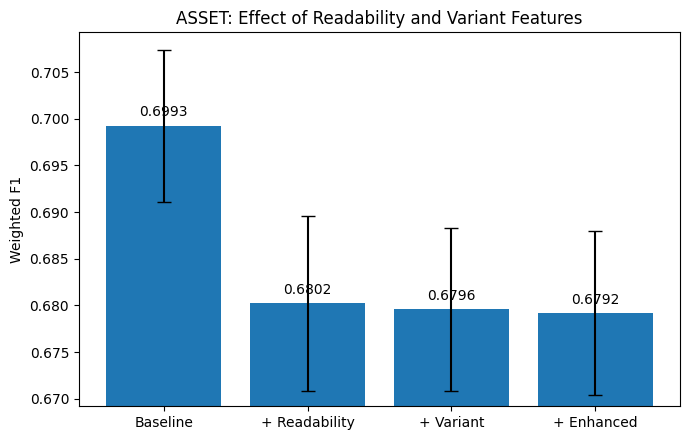

In [27]:
import matplotlib.pyplot as plt
import numpy as np

config_order = [
    "Baseline: Char TF-IDF + LinearSVC",
    "Baseline + Readability",
    "Baseline + Readability + Variant",
    "Baseline + Readability + Variant + Enhanced"
]

short_labels = [
    "Baseline",
    "+ Readability",
    "+ Variant",
    "+ Enhanced"
]

plot_df = (
    results_asset
    .groupby("config")["weighted_f1"]
    .agg(["mean", "std"])
    .loc[config_order]
    .reset_index()
)

x = np.arange(len(plot_df))

plt.figure(figsize=(7,4.5))

plt.bar(
    x,
    plot_df["mean"],
    yerr=plot_df["std"],
    capsize=5
)

plt.xticks(x, short_labels)
plt.ylabel("Weighted F1")
plt.title("ASSET: Effect of Readability and Variant Features")

y_min = plot_df["mean"].min() - 0.01
y_max = plot_df["mean"].max() + 0.01

plt.ylim(y_min, y_max)

for i, value in enumerate(plot_df["mean"]):
    plt.text(
        i,
        value + 0.001,
        f"{value:.4f}",
        ha="center",
        fontsize=10
    )

plt.tight_layout()

plt.savefig(
    "asset_weighted_f1_barplot.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()